# Set Up

In [1]:
# In case switch to PyTorch becomes necessary
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")



C:\Users\Patrik\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 3.14.0
Keras backend: tensorflow


In [2]:
with open('../../Datasets/Texts/Hamlet/gutenberg-hamlet-cleaned.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 176430 characters
First 100 characters: SCENE. Elsinore.




ACT I

SCENE I. Elsinore. A platform before the Castle.


Enter Francisco and B


# Building The Model

## Training SentencePiece Model

In [3]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'hamlet_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 1000
model_prefix = 'hamlet_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "To be, or not to be, that is the question:"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁To', '▁be', ',', '▁or', '▁not', '▁to', '▁be', ',', '▁that', '▁is', '▁the', '▁question', ':']
Vocabulary size: 1000


## Preparing The Data

In [4]:
# Tokenize the text
seq_length = 32
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 60677
Number of sequences: 60645
Input shape: (60645, 32)
Target shape: (60645, 32)


In [5]:
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 64
num_heads = 4
ff_dim = 128
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 32, 64)    │     64,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 64)    │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 32, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 32, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32, 1000)  │     65,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 195,944 (765.41 KB)

 Trainable params: 195,944 (765.41 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
batch_size = 128
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('hamlet_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 64s 148ms/step - accuracy: 0.0424 - loss: 6.4509 - val_accuracy: 0.0563 - val_loss: 6.1137 - learning_rate: 5.0000e-05
Epoch 2/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 146ms/step - accuracy: 0.0551 - loss: 6.0237 - val_accuracy: 0.0603 - val_loss: 5.9651 - learning_rate: 5.0000e-05
Epoch 3/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - accuracy: 0.0618 - loss: 5.9514 - val_accuracy: 0.0689 - val_loss: 5.9295 - learning_rate: 5.0000e-05
Epoch 4/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 156ms/step - accuracy: 0.0754 - loss: 5.8258 - val_accuracy: 0.0878 - val_loss: 5.6380 - learning_rate: 5.0000e-05
Epoch 5/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.0968 - loss: 5.4710 - val_accuracy: 0.1070 - val_loss: 5.2473 - learning_rate: 5.0000e-05
Epoch 6/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 158ms/step - accuracy: 0.1166 - loss: 5.1502 - val_accuracy: 0.1271 - val_loss: 4.9899 - learning_rate: 5.0000e-05
Epoch 7/100
380/380 ━━━━━━━━━━━━━━━━━━━━

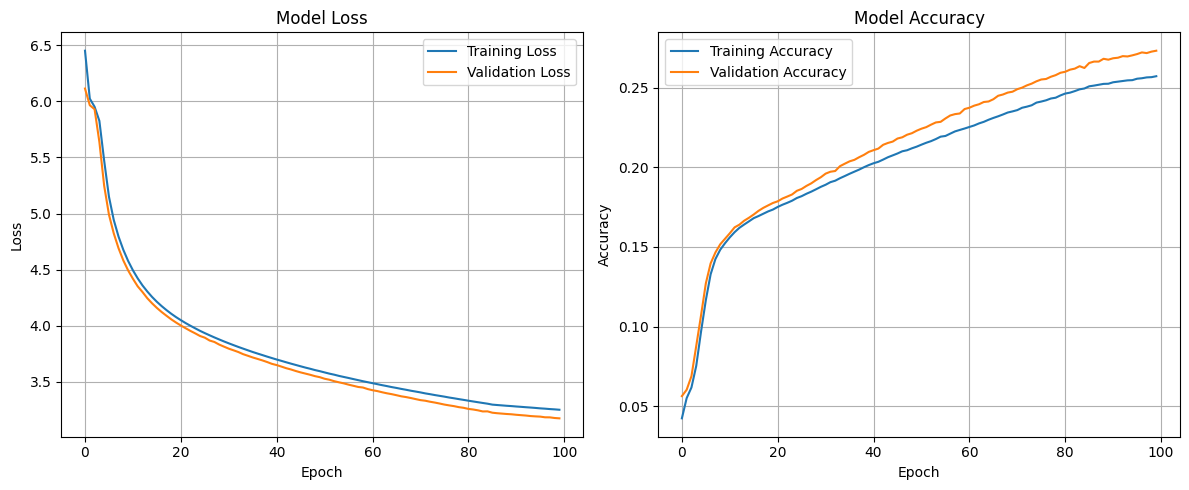

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [9]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

ACT I SCENE  ⁇ . A room in the Castle. Enter King and Queen. HAMLET. Sir, my lord. HAMLET. I’ll follow thee. I am, sir. [_Exit._] HAMLET. Indeed, my lord. HAMLET. I’ll be. I am, sir, sir, sir, I’ll have a pardon’d, and the corrow of the phrase, and dustom, and his minents. [_Exit


In [10]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

ACT I SCENE  ⁇ . Make. Another room in the Castle.Rostady, Laertes, Laertes. POLONIUS. We melow, my lord? A faithful e’tiness. Dane, no tongue, That you, It is the most true and carnin to the end. BARNARDO. What is a fight? FIRST CLOWN. Ay, I will, sir. HAMLET. What is this misesome answer, flowers, sir. [_S


In [11]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

ACT I SCENE  ⁇ . Will mother to himself; str first a done, Nor doance of Fortinbran else their ear grief, takeesty, though one; [_Lollow So he one contorm’t wat; if they much so clorm on haves you, mine pray by a guilt did shot artle, be some brazan in feary pr Bruly eyes made him beish that so With ent friend? [_iseath eyesith


In [12]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

HAMLET. I’ll be the matter. [_Exit._] KING. O, my lord, I am sorrow. HAMLET. I am, my lord. HAMLET. I’ll follow thee. [_To Polonius._] O, my lord, I am sicked, and youthing, and the prased, and damny. HAMLET. I’ll call it. [_Exeunt._] SCENE II. A room in the Castle. Enter Hamlet and Horatio


In [13]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

HAMLET. Aparted, And can I am, as the very grit, A kepunder the quick of that weed on my daughter, To show me for matter. Say, mark, Come away. [_Exeunt Rosencrantz and Guildenstern Guildenstern! O, Queen sently? HAMLET. I will speak. It was an acted. BARNARDO. We gove them well to been age. LAERTES. How comes, sir. [_Sings._] But


In [14]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

HAMLET. Give these nroon Barnep commages, Where act thee then will smrease honour’d it most bawicious snitor that hor shring cha chiege—im, fenter cwliar,— mine eye will return the lapers faul her: then some art blows as whar father’r Py Ophelia in Ereakach neg out arow Honwe seen come about to speak


In [15]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

To be, or not to be, that is the question: For ’tis a further air, and the minage of the country, and the minage of the minage of the King. HAMLET. I’ll be well. [_To Rosencrantz and Guildenstern._] HAMLET. I am, my lord. HAMLET. I’ll follow thee. HAMLET. I will, my lord. HAMLET. I’ll do you, my lord. HAMLET. I’ll have seen you to be. HAMLET. I will


In [16]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

To be, or not to be, that is the question: but by name, I am sungely; And I’ dancom’d, startedg’d to give blood. The thoughts beast of witch; and is. God, the minches have kill. HAMLET. Why, I, wised all his lay leave to old assay again, No, as they shall be so than it. ROSENCRANTZ. But what I have done. HAMLET. Sir, and will se


In [17]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

To be, or not to be, that is the question: ‘Weolding that if here the voyanceal fives true; there else. Mark thee best Ophelia, fhanseless The gagancheiol. Now replon? OSRIC. Fordo not. Look yet goodither it me see wellzardofill our repet To keep her his grave lookke hour’te word unlleig some dist-nious audit; let beabay Cot


# Conclusions

## Initial Findings
Model name: **hamlet-model-1to1**  
Initial construction of the model was done precisely and identically following the provided material, with the only exception being changind the vocab size for the SentencePiece model training, to reflect a smaller dataset.  
In addition due to hardware limitations the the number of epochs needed to be reduced to mere 10, which yielded testing accuracy of **0.2550** and validation accuracy of **0.2640**.  
Even so the training time was little over an hour.  

The model does not perform well with low temperature (tested at **0.2**) values with its input unraveling to repetetion almost immediately after the first sentence.  
Temperature value of **0.9** provides the most coherent outputs with enough creativity to produce something different from the source material, though this too is easily prone to repetition.  
If temperature value is set to its most creative at values beyond **1.5** the model utterly falls apart in an attempt to poetically mix tokens to nonsensical ends.  

With values in the medium temperature area or below the model is still able to maintain the structure of the original source material in respects to designating names of characters before their spoken lines. The one thing the model seemingly hasn't grasped gotten proper grasp on is stage directions and scene establishments.  

Next test will focus on tuning the various hyperparameters to find the minimum viable values for a sensible model on low-end systems.  

Transformer-blokkien määrä (num_layers), upotusavaruuden dimensio (embed_dim), sanaston koko (vocab_size) ja fully connected -kerroksen leveys (ff_dim, usein tosin 2*embed_dim)

## Minimum Viable Model  
### First Attempt

Hyperparameter values:  
vocab_size = 1000  
seq_length = 32  
num_layers = 2   
embed_dim = 64  
ff_dim = 128 

Epochs = 10

Training time of the model significantly improves taking only 10 minutes.  
The quality of the model however suffers greatly. Training accuracy drops down to **0.1523** and validation accuracy to **0.1570**.  
The generated prompts are also nonsensical on every temperature level. Only the coldest temperature levels (tested at **0.2**) manage to retain legible words. All levels above result in mostly unrecognizeable token combination.  

However due to the lowered training time of the model, and graph that indicate no signs of overfitting this opens up the possibility to increase unrestrain the number of epochs.  

### Second Attempt  

Model name: **hamlet-model-min**  
All hyperparameter values are retained from the first attempt, but epochs will be increased to 100, giving a maximum training time more or less comparable to the one detailed in initial findings (when working on low-end system).  

Epochs = 100

Model reaches training accuracy of **0.2571** and validation accuracy of **0.2731**.  
The model produces accuracy values equivalent to the initial model, meaning size-wise the minimalisation of the model was a success.  
Training duration wise they both take equal time.  
By sheer subjective overview of the prompt results the quality seems to be higher with this particular model.  
This is supported by comparison of their training and validation loss over time.  
Whereas the initial model's training had to be cut short due to hardware limitation thus never allowing for the graph to find its natural point of "plateauing", this model manages to reach such point at around 80 epoch mark.

In [18]:
#model.save('hamlet-model-min.keras')
#print("Model saved as 'hamlet-model-min.keras'")

Model saved as 'hamlet-model-1to1.keras'
